In [1]:
import sys
sys.path.append('../..')

import os
import json
import qiskit
import warnings
import pandas as pd
import numpy as np
import rustworkx as rx
from typing import List
from natsort import natsorted
from phoenix.models import HamiltonianModel
from phoenix.utils import arch
from qiskit.transpiler import CouplingMap
import matplotlib.pyplot as plt
from bench_utils import Manhattan, All2all

warnings.filterwarnings("ignore")

In [2]:
json_dpath = '../benchmarks/qaoa'
json_fnames = natsorted(os.listdir(json_dpath))

In [3]:
json_fnames

['rand_16.json',
 'rand_20.json',
 'rand_24.json',
 'reg3_16.json',
 'reg3_20.json',
 'reg3_24.json']

**2QAN results on Manhattan:**



In [7]:
num_2q_2qan = []
depth_2q_2qan = []
twoqan_hhex_output_dpath = './output_qaoa/2qan_hhex'
for fname in os.listdir(twoqan_hhex_output_dpath):
    fname = os.path.join(twoqan_hhex_output_dpath, fname)
    qc = qiskit.QuantumCircuit.from_qasm_file(fname)
    num_2q_2qan.append(qc.num_nonlocal_gates())
    depth_2q_2qan.append(qc.depth(lambda instr: instr.operation.num_qubits > 1))


In [8]:
print('2QAN Num2Q:', num_2q_2qan)
print('2QAN Depth2Q:', depth_2q_2qan)

2QAN Num2Q: [170, 223, 219, 274, 186, 148]
2QAN Depth2Q: [85, 64, 89, 100, 48, 61]


In [9]:
def qiskit_O3_all2all(circ: qiskit.QuantumCircuit) -> qiskit.QuantumCircuit:
    from itertools import combinations
    for q0, q1 in combinations(range(circ.num_qubits), 2):
        circ.cx(q0, q1)
        circ.cx(q0, q1)
    circ = qiskit.transpile(circ, optimization_level=3, basis_gates=['u1', 'u2', 'u3', 'cx'])
    return circ

def is_all2all_coupling_map(coupling_map: CouplingMap) -> bool:
    # ! coupling_map.graph is a directed coupling map
    if coupling_map.size() * (coupling_map.size() - 1) == len(coupling_map.get_edges()):
        return True
    return False

def phoenix_pass(paulis: List[str], coeffs: List[float], coupling_map: CouplingMap) -> qiskit.QuantumCircuit:
    """Phoenix's high-level optimization"""
    ham = HamiltonianModel(paulis, coeffs)
    # circ = ham.reconfigure_and_generate_circuit() # this is the old version
    circ = ham.phoenix_circuit()

    circ = qiskit_O3_all2all(circ.to_qiskit())  # since input is logical circuit, we can first ally a all2all Qiskit O3
    if is_all2all_coupling_map(coupling_map):
        return circ
    circ = qiskit.transpile(circ, optimization_level=3,
                            basis_gates=['u1', 'u2', 'u3', 'cx'],
                            coupling_map=coupling_map, layout_method='sabre')
    return circ


def phoenix_pass_num_swap(paulis, coeffs, coupling_map):
    ham = HamiltonianModel(paulis, coeffs)
    # circ = ham.reconfigure_and_generate_circuit() # this is the old version
    circ = ham.phoenix_circuit()

    circ = qiskit_O3_all2all(circ.to_qiskit())  # since input is logical circuit, we can first ally a all2all Qiskit O3

    circ = qiskit.transpile(circ, optimization_level=3,
                            basis_gates=['u1', 'u2', 'u3', 'cx', 'swap'],
                            coupling_map=coupling_map, layout_method='sabre')
    return circ.count_ops()['swap']

In [23]:
num_2q_phoenix = []
depth_2q_phoenix = []
for fname in json_fnames:
    fname = os.path.join(json_dpath, fname)
    with open(fname, 'r') as f:
        data = json.load(f)
    
    circ = phoenix_pass(data['paulis'], data['coeffs'], Manhattan)
    num_2q_phoenix.append(circ.num_nonlocal_gates())
    depth_2q_phoenix.append(circ.depth(lambda instr: instr.operation.num_qubits > 1))



In [24]:
print('Phoenix Num2Q:', num_2q_phoenix)
print('Phoenix Depth2Q:', depth_2q_phoenix)

Phoenix Num2Q: [161, 184, 248, 97, 119, 153]
Phoenix Depth2Q: [51, 46, 54, 31, 31, 29]


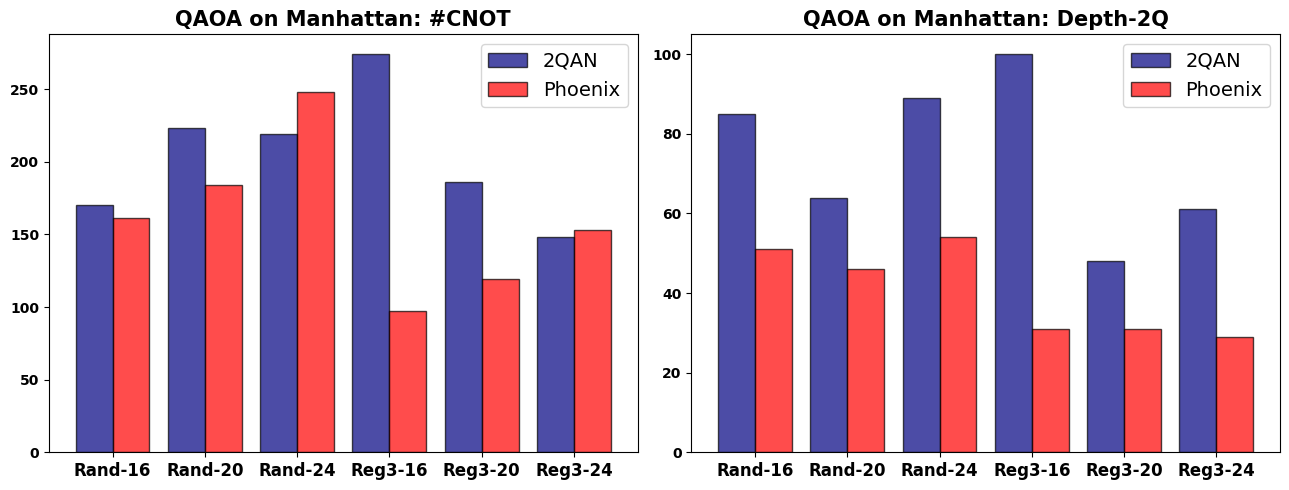

In [25]:
plt.figure(figsize=(13, 5))


plt.subplot(1, 2, 1)
width = 0.4
xticks = [fname.rstrip('.json').replace('_', '-').capitalize() for fname in json_fnames]
plt.bar(np.arange(len(xticks)) - 0.5 * width, num_2q_2qan, width=width, label='2QAN', color='navy', alpha=0.7, edgecolor='black')
plt.bar(np.arange(len(xticks)) + 0.5 * width, num_2q_phoenix, width=width, label='Phoenix', color='red', alpha=0.7, edgecolor='black')
plt.xticks(range(len(xticks)), xticks, fontsize=12, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.yticks(fontweight='bold')
plt.title('QAOA on Manhattan: #CNOT', fontsize=15, fontweight='bold')

plt.subplot(1, 2, 2)
plt.bar(np.arange(len(xticks)) - 0.5 * width, depth_2q_2qan, width=width, label='2QAN', color='navy', alpha=0.7, edgecolor='black')
plt.bar(np.arange(len(xticks)) + 0.5 * width, depth_2q_phoenix, width=width, label='Phoenix', color='red', alpha=0.7, edgecolor='black')
plt.xticks(range(len(xticks)), xticks, fontsize=12, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.yticks(fontweight='bold')
plt.title('QAOA on Manhattan: Depth-2Q', fontsize=15, fontweight='bold')


plt.tight_layout()
# plt.savefig('../figures/qaoa.pdf')


In [26]:
for fname in json_fnames:
    json_fname = os.path.join(json_dpath, fname)
    with open(json_fname, 'r') as f:
        data = json.load(f)

    ham = HamiltonianModel(data['paulis'], data['coeffs'])
    circ = ham.generate_circuit()

    print(fname, data['num_qubits'], len(data['paulis']), circ.num_nonlocal_gates, circ.depth_nonlocal)

rand_16.json 16 32 64 36
rand_20.json 20 40 80 32
rand_24.json 24 48 96 48
reg3_16.json 16 24 48 18
reg3_20.json 20 30 60 22
reg3_24.json 24 36 72 20


### Detailed data for table

In [ ]:
result_2qan = pd.DataFrame(columns=['fname', 'num_qubits', 'num_paulis',
                                    'num_cnot(all2all)', 'depth_2q(all2all)',
                                    'num_cnot(manhattan)', 'depth_2q(manhattan)',
                                    'num_swap(manhatten)'])
result_phoenix = pd.DataFrame(columns=['fname', 'num_qubits', 'num_paulis',
                                       'num_cnot(all2all)', 'depth_2q(all2all)',
                                       'num_cnot(manhattan)', 'depth_2q(manhattan)',
                                       'num_swap(manhatten)'])
for fname in json_fnames:
    json_fname = os.path.join(json_dpath, fname)
    with open(json_fname, 'r') as f:
        data = json.load(f)

    ham = HamiltonianModel(data['paulis'], data['coeffs'])
    circ = ham.generate_circuit()

    result_2qan = pd.concat([result_2qan, pd.DataFrame({'fname': fname.strip('.json'), 'num_qubits': data['num_qubits'], 'num_paulis': len(data['paulis'])}, index=[0])], ignore_index=True)
    result_phoenix = pd.concat([result_phoenix, pd.DataFrame({'fname': fname.strip('.json'), 'num_qubits': data['num_qubits'], 'num_paulis': len(data['paulis'])}, index=[0])], ignore_index=True)


In [29]:
np.random.seed(123)
for fname in json_fnames:
    json_fname = os.path.join(json_dpath, fname)
    with open(json_fname, 'r') as f:
        data = json.load(f)

    # all2all mapping
    circ = phoenix_pass(data['paulis'], data['coeffs'], coupling_map=All2all)
    result_phoenix.loc[result_phoenix['fname'] == fname, 'num_cnot(all2all)'] = circ.num_nonlocal_gates()
    result_phoenix.loc[result_phoenix['fname'] == fname, 'depth_2q(all2all)'] = circ.depth(lambda instr: instr.operation.num_qubits > 1)
    
    # manhattan mapping
    num_cnot = []
    depth_2q = []
    for _ in range(50):
        circ = phoenix_pass(data['paulis'], data['coeffs'], coupling_map=Manhattan)
        num_cnot.append(circ.num_nonlocal_gates())
        depth_2q.append(circ.depth(lambda instr: instr.operation.num_qubits > 1))
    result_phoenix.loc[result_phoenix['fname'] == fname, 'num_cnot(manhattan)'] = np.mean(num_cnot).astype(int)
    result_phoenix.loc[result_phoenix['fname'] == fname, 'depth_2q(manhattan)'] = np.mean(depth_2q).astype(int)
    num_swap = []
    for _ in range(50):
        num_swap.append(phoenix_pass_num_swap(data['paulis'], data['coeffs'], coupling_map=Manhattan))
    result_phoenix.loc[result_phoenix['fname'] == fname, 'num_swap(manhatten)'] = np.mean(num_swap).astype(int)

In [30]:
result_phoenix['num_cnot(manhattan)'] = result_phoenix['num_cnot(manhattan)'].astype(int)
result_phoenix['depth_2q(manhattan)'] = result_phoenix['depth_2q(manhattan)'].astype(int)
result_phoenix['num_swap(manhatten)'] = result_phoenix['num_swap(manhatten)'].astype(int)

In [31]:
result_phoenix

,fname,num_qubits,num_paulis,num_cnot(all2all),depth_2q(all2all),num_cnot(manhattan),depth_2q(manhattan),num_swap(manhatten)
0,rand_16.json,16,32,64,18,148,50,29
1,rand_20.json,20,40,80,14,189,53,39
2,rand_24.json,24,48,96,16,249,64,54
3,reg3_16.json,16,24,48,8,98,27,17
4,reg3_20.json,20,30,60,10,125,29,23
5,reg3_24.json,24,36,72,10,155,34,30


In [32]:
result_phoenix.to_csv('./results/qaoa_phoexix.csv', index=False)

In [34]:
for fname in json_fnames:
    json_fname = os.path.join(json_dpath, fname)
    with open(json_fname, 'r') as f:
        data = json.load(f)

    # all2all mapping
    circ = phoenix_pass(data['paulis'], data['coeffs'], coupling_map=All2all)
    # result_phoenix.loc[result_phoenix['fname'] == fname, 'num_cnot(all2all)'] = circ.num_nonlocal_gates()
    # result_phoenix.loc[result_phoenix['fname'] == fname, 'depth_2q(all2all)'] = circ.depth(lambda instr: instr.operation.num_qubits > 1)
    print(fname, circ.num_nonlocal_gates(), circ.depth(lambda instr: instr.operation.num_qubits > 1))
    

rand_16.json 64 18
rand_20.json 80 14
rand_24.json 96 16
reg3_16.json 48 8
reg3_20.json 60 10
reg3_24.json 72 10


In [36]:
result_phoenix

,fname,num_qubits,num_paulis,num_cnot(all2all),depth_2q(all2all),num_cnot(manhattan),depth_2q(manhattan),num_swap(manhatten)
0,rand_16.json,16,32,64,18,148,50,29
1,rand_20.json,20,40,80,14,189,53,39
2,rand_24.json,24,48,96,16,249,64,54
3,reg3_16.json,16,24,48,8,98,27,17
4,reg3_20.json,20,30,60,10,125,29,23
5,reg3_24.json,24,36,72,10,155,34,30


### Read files

In [58]:
result_phoenix = pd.read_csv('./results/qaoa_phoexix.csv')
result_2qan = pd.read_csv('./results/qaoa_2qan.csv')

In [59]:
blue_col = plt.cm.Blues(np.linspace(0.3, 0.9, 3)).tolist()[1]

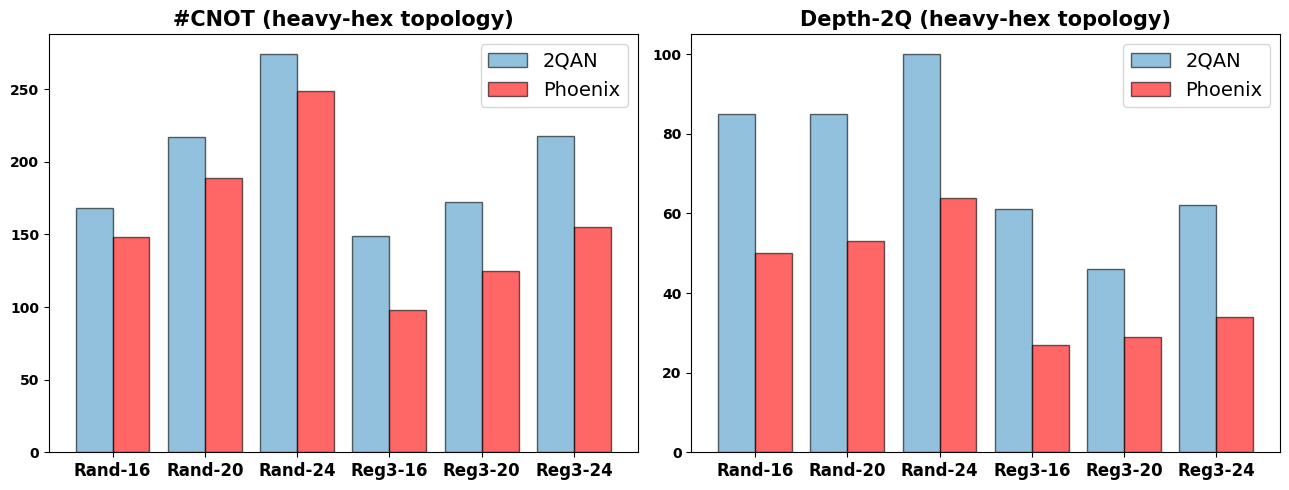

In [60]:
plt.figure(figsize=(13, 5))


plt.subplot(1, 2, 1)
width = 0.4
xticks = [fname.rstrip('.json').replace('_', '-').capitalize() for fname in json_fnames]
plt.bar(np.arange(len(xticks)) - 0.5 * width, result_2qan['num_cnot(manhattan)'], width=width, label='2QAN', color=blue_col, alpha=0.6, edgecolor='black')
plt.bar(np.arange(len(xticks)) + 0.5 * width, result_phoenix['num_cnot(manhattan)'], width=width, label='Phoenix', color='red', alpha=0.6, edgecolor='black')
plt.xticks(range(len(xticks)), xticks, fontsize=12, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.yticks(fontweight='bold')
plt.title('#CNOT (heavy-hex topology)', fontsize=15, fontweight='bold')

plt.subplot(1, 2, 2)
plt.bar(np.arange(len(xticks)) - 0.5 * width, result_2qan['depth_2q(manhattan)'], width=width, label='2QAN', color=blue_col, alpha=0.6, edgecolor='black')
plt.bar(np.arange(len(xticks)) + 0.5 * width, result_phoenix['depth_2q(manhattan)'], width=width, label='Phoenix', color='red', alpha=0.6, edgecolor='black')
plt.xticks(range(len(xticks)), xticks, fontsize=12, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.yticks(fontweight='bold')
plt.title('Depth-2Q (heavy-hex topology)', fontsize=15, fontweight='bold')


plt.tight_layout()
plt.savefig('./figures/qaoa.pdf')


In [62]:
result_phoenix

,fname,num_qubits,num_paulis,num_cnot(all2all),depth_2q(all2all),num_cnot(manhattan),depth_2q(manhattan),num_swap(manhatten)
0,rand_16,16,32,64,18,148,50,29
1,rand_20,20,40,80,14,189,53,39
2,rand_24,24,48,96,16,249,64,54
3,reg3_16,16,24,48,8,98,27,17
4,reg3_20,20,30,60,10,125,29,23
5,reg3_24,24,36,72,10,155,34,30


In [63]:
result_phoenix['routing_overhead'] = round(result_phoenix['num_cnot(manhattan)'] / result_phoenix['num_cnot(all2all)'], 2)
result_2qan['routing_overhead'] = round(result_2qan['num_cnot(manhattan)'] / result_2qan['num_cnot(all2all)'], 2)

In [64]:
from scipy.stats import gmean
print('num_cnot reduction', gmean(1 - result_phoenix['num_cnot(manhattan)'] / result_2qan['num_cnot(manhattan)']).round(4))
print('depth_2q reduction', gmean(1 - result_phoenix['depth_2q(manhattan)'] / result_2qan['depth_2q(manhattan)']).round(4))
print('num_swap reduction', gmean(1 - result_phoenix['num_swap(manhatten)'] / result_2qan['num_swap(manhatten)']).round(4))
print('routing overhead', gmean(1 - result_phoenix['routing_overhead'] / result_2qan['routing_overhead']).round(4))

num_cnot reduction 0.1833
depth_2q reduction 0.4161
num_swap reduction 0.3067
routing overhead 0.1834


In [65]:
comparison = pd.merge(
    result_2qan, result_phoenix,
    on=['fname', 'num_qubits', 'num_paulis'],
    suffixes=('(2qan)', '(phoenix)')
)

In [66]:
df_part = comparison[['fname', 'num_qubits', 'num_paulis',
            'num_cnot(manhattan)(2qan)', 'num_cnot(manhattan)(phoenix)', 
            'depth_2q(manhattan)(2qan)', 'depth_2q(manhattan)(phoenix)',
            'num_swap(manhatten)(2qan)', 'num_swap(manhatten)(phoenix)',
            'routing_overhead(2qan)', 'routing_overhead(phoenix)']]
df_part

,fname,num_qubits,num_paulis,num_cnot(manhattan)(2qan),num_cnot(manhattan)(phoenix),depth_2q(manhattan)(2qan),depth_2q(manhattan)(phoenix),num_swap(manhatten)(2qan),num_swap(manhatten)(phoenix),routing_overhead(2qan),routing_overhead(phoenix)
0,rand_16,16,32,168,148,85,50,37,29,2.62,2.31
1,rand_20,20,40,217,189,85,53,47,39,2.71,2.36
2,rand_24,24,48,274,249,100,64,63,54,2.85,2.59
3,reg3_16,16,24,149,98,61,27,44,17,3.10,2.04
4,reg3_20,20,30,172,125,46,29,46,23,2.87,2.08
5,reg3_24,24,36,218,155,62,34,62,30,3.03,2.15


In [ ]:
# df_part.to_latex('qaoa.tex', index=False)

In [69]:
np.random.seed(123)

json_fname = os.path.join(json_dpath, 'qaoa_rand_16' + '.json')
with open(json_fname, 'r') as f:
    data = json.load(f)

# all2all mapping
circ = phoenix_pass(data['paulis'], data['coeffs'], coupling_map=All2all)
   

In [70]:
circ.draw(fold=300)

global phase: 3.7021
                                                                                                                                                                                                                                                                                                   »
 q_0: ──■─────────────────────────────■──────────────────────────────────────────────────────────────────────────■─────────────────────────────────────────────────■──────────────────────────────────■───────────────────────────────────────■─────────■──────────────────────────────────────────»
        │                             │                                                                          │                                                 │                                  │                                       │         │                                          »
 q_1: ──┼────■────────────────────────┼─────────■────────────────────────■───────────────────────────────────────┼──────────────────────────────────■──────────────┼──────────────────────────────────┼───────────────────────────────────────┼─────────┼───────────────────■──────────────────────»
      ┌─┴─┐  │  ┌─────────────┐     ┌─┴─┐       │                        │                                       │                                  │              │                                  │                                       │         │                   │                      »
 q_2: ┤ X ├──┼──┤ U1(0.94672) ├─────┤ X ├───────┼───────────────────■────┼───────────────────────────────────────┼────────────────────────■─────────┼──────────────┼─────────■────────────────────────┼─────────────────────────────■─────────┼─────────┼─────────■─────────┼──────────────────────»
      └───┘  │  └─────────────┘     └───┘       │                   │    │                                       │                        │         │              │         │                        │                             │         │         │         │         │                      »
 q_3: ───────┼─────────■────────────────────────┼─────────■─────────┼────┼───────────────────────────────────────┼────■───────────────────┼─────────┼──────────────┼────■────┼────────────────────────┼─────────────────────────────┼─────────┼─────────┼─────────┼─────────┼─────────■────────────»
             │         │                        │         │         │    │                                       │    │                   │         │              │    │    │                        │                             │         │         │         │         │         │            »
 q_4: ──■────┼─────────┼────────────────────────┼────■────┼─────────┼────┼──────────────────────────────────■────┼────┼───────────────────┼─────────┼─────────■────┼────┼────┼────────────────────────┼─────────────────────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼────────────»
        │  ┌─┴─┐       │       ┌─────────────┐┌─┴─┐  │    │         │    │                                  │    │    │                   │         │         │    │    │    │                        │                             │         │         │         │         │         │            »
 q_5: ──┼──┤ X ├───────┼───────┤ U1(0.94672) ├┤ X ├──┼────┼─────────┼────┼─────────■────────────────────────┼────┼────┼───────────────────┼────■────┼─────────┼────┼────┼────┼─────────■──────────────┼─────────────────────────────┼────■────┼─────────┼─────────┼─────────┼─────────┼────────────»
        │  └───┘       │       └─────────────┘└───┘  │    │         │    │         │                        │    │    │                   │    │    │         │    │    │    │         │              │                             │    │    │         │         │         │         │            »
 q_6: ──┼────■─────────┼─────────────────────────────┼────┼────■────┼────┼─────────┼──────────────■─────────┼────┼────┼───────────────────┼────┼────┼────■────┼────┼────┼─